In [3]:
import numpy as np
import seaborn as sns
import pandas as pd
from AGNoptspecNN.model.preprocess import *
from AGNoptspecNN.model.training_cnn import *

**Load the spectra and interpolate it to say a given number of points.**

In [4]:
SPECTRA_DIR="/home/tathagata/Documents/coding/AGNspecCNN/simulated_spectra/"

p1 = preprocess_1D_spectra(f"{SPECTRA_DIR}/type1/")
p2 = preprocess_1D_spectra(f"{SPECTRA_DIR}/type1pt9/")
p3 = preprocess_1D_spectra(f"{SPECTRA_DIR}/type2/")

p1.nx = 1000
p2.nx = 1000
p3.nx = 1000

**Read the files.**

In [5]:
X1, y1 = p1.read_files()
X2, y2 = p2.read_files()
X3, y3 = p3.read_files()

**Concatenate the spectra and shuffle them.**
- Make sure that the spectra are shuffled such X and y labels remain consistent.

In [ ]:
X = np.concatenate((X1, X2, X3), axis=0)
y = np.concatenate((y1, y2, y3), axis=0)

print(f"X-shape:{X.shape}")
print(f"y-shape:{y.shape}")

idx = np.arange(0, y.size)
idx1 = np.copy(idx)

np.random.shuffle(idx1) #<-------- shuffling

y_shuf = y[idx1]
X_shuf = X[idx1]

X-shape:(30000, 1000, 1)
y-shape:(30000,)


**Model training**

Test train split:

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_shuf, y_shuf, test_size=0.2)

In [ ]:
n1 = cnn_trainer() # Define the class first.

n1.X_train = X_train
n1.y_train = y_train

n1.X_test = X_test
n1.y_test = y_test

n1.input_dim = X_train[0].shape

n1.epochs = 50
n1.input_dim = n1.X_train.shape[1:3]

print(n1.input_dim)

(1000, 1)


In [8]:
n1.model_compile()
n1.model.summary()

2025-08-07 17:09:20.277811: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 1000, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 981, 4)         │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 245, 4)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 242, 2)         │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 60, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        15,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,521 (103.60 KB)

 Trainable params: 26,521 (103.60 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
run_history = n1.train(verbose=1)

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.5779 - sparse_categorical_accuracy: 0.7198 - val_loss: 0.3875 - val_sparse_categorical_accuracy: 0.8358
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3687 - sparse_categorical_accuracy: 0.8489 - val_loss: 0.2426 - val_sparse_categorical_accuracy: 0.9096
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2500 - sparse_categorical_accuracy: 0.9092 - val_loss: 0.1554 - val_sparse_categorical_accuracy: 0.9435
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1654 - sparse_categorical_accuracy: 0.9426 - val_loss: 0.1269 - val_sparse_categorical_accuracy: 0.9554
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1252 - sparse_categorical_accuracy: 0.9580 - val_loss: 0.0854 - val_sparse_categorical_accuracy: 0.9708
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.0992 - sparse_categorical_accuracy: 0.9660 - val_loss: 0.0563 - val_sparse_categorical_accuracy: 0.9800
Epoc

In [10]:
history = pd.DataFrame(run_history.history)

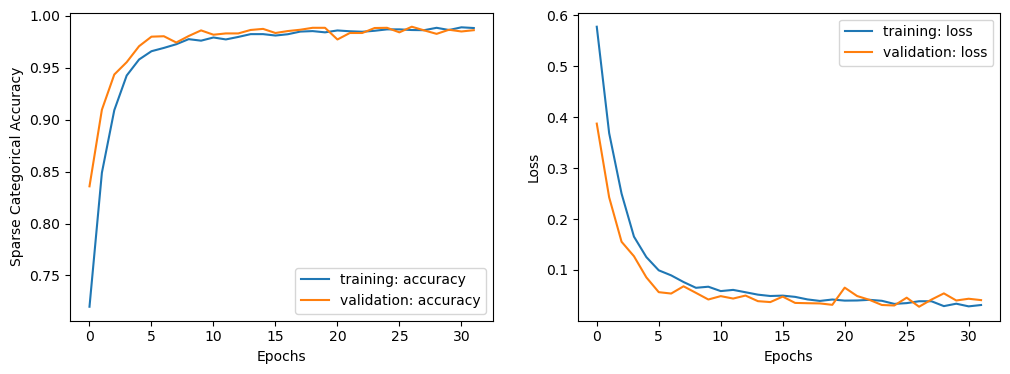

In [11]:
n1.performance()

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0492 - sparse_categorical_accuracy: 0.9840
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
===== Metrics of the test-data =====
              precision    recall  f1-score   support

         0.0       0.99      0.98      0.99      2007
         1.0       0.98      0.98      0.98      2021
         2.0       0.98      0.99      0.98      1972

    accuracy                           0.98      6000
   macro avg       0.98      0.98      0.98      6000
weighted avg       0.98      0.98      0.98      6000



Text(45.722222222222214, 0.5, 'Truth')

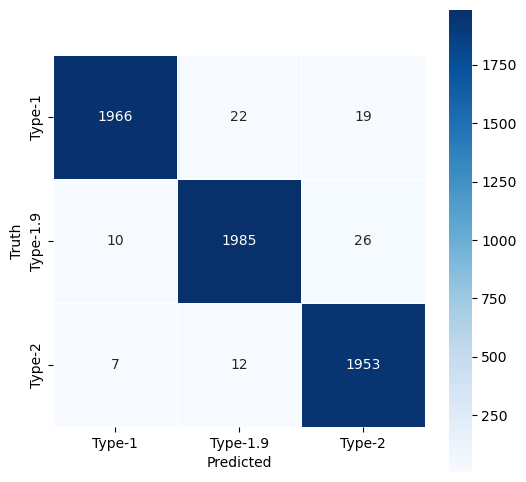

In [13]:
n1.model.evaluate(X_test, y_test)
n1.tests(which="test")

labels = ['Type-1', 'Type-1.9', 'Type-2']

plt.figure(figsize=(6,6))
sns.heatmap(n1.cm, annot=True, fmt='d', linewidths=.5, square = True, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Truth')

**Save the model.**

In [ ]:
# n1.model_save(path="PATH_TO_SAVED_MODEL", filename="model.keras")